In [1]:
pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 73.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.2 MB/s eta 0:00:00:00:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import math
import random
import time
import pandas as pd

In [2]:
model_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto",
    attn_implementation="eager",
)

model.eval()

print(type(model).__name__)
print("device:", next(model.parameters()).device)
print("dtype:", next(model.parameters()).dtype)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM
device: cuda:0
dtype: torch.bfloat16


In [3]:
prompt = "KV cache compression is useful because"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
generated_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"] #padding if needed

# PREFILL
# Run a forward pass on the full prompt.
# This fills the KV cache with the prompt tokens.
with torch.no_grad():
    out = model(
        input_ids=generated_ids,     # the full prompt
        attention_mask=attention_mask,
        use_cache=True,              # ask the model to return the cache
        return_dict=True,            # return outputs as an object with named fields
    )

cache = out.past_key_values
print("type(cache):", type(cache))
print("logits.shape:", tuple(out.logits.shape))
print("prompt token len:", inputs["input_ids"].shape[1])

print("num cache layers:", len(cache.layers))
print("seq_len layer 0:", cache.get_seq_length(0))

layer0 = cache.layers[0]
print("layer0 type:", type(layer0))
print("K shape:", tuple(layer0.keys.shape))
print("V shape:", tuple(layer0.values.shape))

type(cache): <class 'transformers.cache_utils.DynamicCache'>
logits.shape: (1, 6, 151936)
prompt token len: 6
num cache layers: 36
seq_len layer 0: 6
layer0 type: <class 'transformers.cache_utils.DynamicLayer'>
K shape: (1, 2, 6, 128)
V shape: (1, 2, 6, 128)


In [4]:
print("\n=== MODEL INFO ===")
cfg = model.config
text_cfg = getattr(cfg, "text_config", cfg)

print("model class          :", type(model).__name__)
print("model_type           :", getattr(text_cfg, "model_type", "N/A"))
print("num_hidden_layers    :", getattr(text_cfg, "num_hidden_layers", "N/A"))
print("hidden_size          :", getattr(text_cfg, "hidden_size", "N/A"))
print("num_attention_heads  :", getattr(text_cfg, "num_attention_heads", "N/A"))
print("num_key_value_heads  :", getattr(text_cfg, "num_key_value_heads", "N/A"))
print("head_dim             :", getattr(text_cfg, "head_dim", "N/A"))
print("vocab_size           :", getattr(text_cfg, "vocab_size", "N/A"))
print("max_position_embeddings :", getattr(text_cfg, "max_position_embeddings", "N/A"))
print("use_cache (config)   :", getattr(text_cfg, "use_cache", "N/A"))

print("\n=== OUTPUT INFO ===")
print("logits.shape         :", tuple(out.logits.shape))
print("cache type           :", type(cache))

if hasattr(cache, "get_seq_length"):
    try:
        print("cache seq_len layer0 :", cache.get_seq_length(0))
    except TypeError:
        print("cache seq_len        :", cache.get_seq_length())


=== MODEL INFO ===
model class          : Qwen2ForCausalLM
model_type           : qwen2
num_hidden_layers    : 36
hidden_size          : 2048
num_attention_heads  : 16
num_key_value_heads  : 2
head_dim             : N/A
vocab_size           : 151936
max_position_embeddings : 32768
use_cache (config)   : True

=== OUTPUT INFO ===
logits.shape         : (1, 6, 151936)
cache type           : <class 'transformers.cache_utils.DynamicCache'>
cache seq_len layer0 : 6


## L2 COMPRESSION

In [5]:
@torch.no_grad()
def l2_compress(
    cache,
    keep_ratio: float = 0.6,
    prune_after: int = 2048,
    verbose: bool = False,
    skip_layers = ()
):
    """
    layer.keys.shape   = [B, H_kv, T, D]
    layer.values.shape = [B, H_kv, T, D]
    """
    
    for layer_idx, layer in enumerate(cache.layers):

        if layer_idx in skip_layers:
            continue

        K = layer.keys
        V = layer.values

        B, H_kv, T, D = K.shape

        if T < prune_after:
            continue

        tokens_to_keep = math.ceil(keep_ratio * T)

        # L2 squared score of the keys
        # Shape: [B, H_kv, T]
        scores = K.float().square().sum(dim=-1)

        # Shape: [B, H_kv, tokens_to_keep]
        keep_idx = torch.topk(
            scores,
            k=tokens_to_keep,
            dim=-1,
            largest=False,
            sorted=False,
        ).indices

        # Restore indices in increasing temporal order
        keep_idx = keep_idx.sort(dim=-1).values

        # From [B, H_kv, T_keep] to [B, H_kv, T_keep, D]
        gather_idx = keep_idx.unsqueeze(-1).expand(-1, -1, -1, D)

        new_K = torch.gather(K, dim=2, index=gather_idx)
        new_V = torch.gather(V, dim=2, index=gather_idx)

        # Update the layer cache
        layer.keys = new_K.contiguous()
        layer.values = new_V.contiguous()

        if verbose:
            print(f"layer {layer_idx}: {T} -> {tokens_to_keep}")

    return cache

## DECODING GENERATION

In [6]:
prune_after = 64
keep_ratio = 0.6
max_new_tokens = 128

prompt = "Write me a function in python that adds two numbers"

# Tokenize the prompt and create PyTorch tensors
# return_tensors="pt" => returns torch tensors
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# input_ids: the prompt tokens, typically with shape [batch=1, prompt_len]
generated_ids = inputs["input_ids"]

# attention_mask: 1 where the token is valid, 0 where padding would be.
# During PREFILL this mask has the same length as the full prompt.
attention_mask = inputs["attention_mask"]

batch_size = generated_ids.shape[0]

# PREFILL
# Run a forward pass on the full prompt.
# This fills the KV cache with the prompt tokens.
with torch.no_grad():
    out = model(
        input_ids=generated_ids,      # the full prompt
        attention_mask=attention_mask,
        use_cache=True,               # ask the model to return the cache
        return_dict=True,             # return outputs as an object with named fields
    )

# Save the cache returned by the model.
cache = out.past_key_values

# Logical position of the next token to be processed.
# If the prompt has length L, the first generated token has logical position L.
# This value must keep growing even if we later compress the physical cache.
logical_pos = generated_ids.shape[1]

# From the logits of the last prompt position, choose the first generated token.
# out.logits has shape [batch, seq_len, vocab_size]
# [:, -1, :] = logits for the last token of the prompt
# argmax = greedy decoding (pick the most likely token)
# keepdim=True => shape [1,1] instead of [1]
next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)

print("prompt token len:", generated_ids.shape[1])
print("cache len after prefill:", cache.layers[0].keys.shape[2])

# AUTOREGRESSIVE DECODE
for step in range(max_new_tokens):

    # Add the token selected at the previous step to the visible generated sequence.
    # The cache is updated only when this token is passed through model(...).
    generated_ids = torch.cat([generated_ids, next_token], dim=-1)

    # Physical length of the compressed cache.
    # This can be smaller than generated_ids.shape[1] after pruning.
    past_len = cache.layers[0].keys.shape[2]

    # Build the attention mask for the CURRENT forward call.
    # With compressed cache, the model can attend only to:
    #   [physical cached tokens] + [current token]
    # Therefore the mask length should be past_len + 1, not len(generated_ids).
    attention_mask_step = torch.ones(
        (batch_size, past_len + 1),
        device=model.device,
        dtype=torch.long,
    )

    # cache_position tells the model the logical/absolute position of the current token.
    # This should NOT be reset after cache compression.
    # Example:
    #   physical cache len may be 39,
    #   but the current token may be logically at position 64 or 100.
    cache_position = torch.tensor(
        [logical_pos],
        device=model.device,
        dtype=torch.long,
    )

    # Run one autoregressive decoding step.
    with torch.no_grad():
        out = model(
            input_ids=next_token,             # pass only the current new token
            attention_mask=attention_mask_step,
            past_key_values=cache,            # reuse the cache built so far
            cache_position=cache_position,    # preserve the logical position for RoPE
            use_cache=True,
            return_dict=True,
        )

    # The current token has now been processed by the model.
    # So the logical position for the next token increases by 1.
    logical_pos += 1

    # The new cache now contains:
    # old physical cache + the newly processed token
    cache = out.past_key_values

    # Optional compression.
    # We check the physical cache length, not the generated sequence length.
    if cache.layers[0].keys.shape[2] >= prune_after:
        before = cache.layers[0].keys.shape[2]

        cache = l2_compress(
            cache,
            keep_ratio=keep_ratio,
            prune_after=prune_after,
            verbose=False,
        )

        after = cache.layers[0].keys.shape[2]
        print(f"COMPRESSED at step {step:02d}: {before} -> {after}")

    # Choose the next token from the logits of the current position.
    next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)

    # Print diagnostic information.
    print(
        f"step {step:02d} | "
        f"logical_pos={logical_pos} | "
        f"physical_cache_len={cache.layers[0].keys.shape[2]}"
    )

# Final decoding of the full sequence into text.
print(tokenizer.decode(generated_ids[0], skip_special_tokens=True))

prompt token len: 10
cache len after prefill: 10
step 00 | logical_pos=11 | physical_cache_len=11
step 01 | logical_pos=12 | physical_cache_len=12
step 02 | logical_pos=13 | physical_cache_len=13
step 03 | logical_pos=14 | physical_cache_len=14
step 04 | logical_pos=15 | physical_cache_len=15
step 05 | logical_pos=16 | physical_cache_len=16
step 06 | logical_pos=17 | physical_cache_len=17
step 07 | logical_pos=18 | physical_cache_len=18
step 08 | logical_pos=19 | physical_cache_len=19
step 09 | logical_pos=20 | physical_cache_len=20
step 10 | logical_pos=21 | physical_cache_len=21
step 11 | logical_pos=22 | physical_cache_len=22
step 12 | logical_pos=23 | physical_cache_len=23
step 13 | logical_pos=24 | physical_cache_len=24
step 14 | logical_pos=25 | physical_cache_len=25
step 15 | logical_pos=26 | physical_cache_len=26
step 16 | logical_pos=27 | physical_cache_len=27
step 17 | logical_pos=28 | physical_cache_len=28
step 18 | logical_pos=29 | physical_cache_len=29
step 19 | logical_po

# ATTENTION VISUALIZZATION

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def get_model_cfg(model):
    """
    Alcuni modelli hanno model.config, altri model.config.text_config.
    Questa funzione gestisce entrambi i casi.
    """
    return getattr(model.config, "text_config", model.config)


def get_cache_layer(cache, layer_idx):
    """
    Supporta sia DynamicCache recente sia vecchio formato tuple/list.
    """
    if hasattr(cache, "layers"):
        layer = cache.layers[layer_idx]
        return layer.keys, layer.values
    else:
        return cache[layer_idx][0], cache[layer_idx][1]


def get_token_labels(tokenizer, input_ids, clean=True):
    """
    Restituisce i token reali del tokenizer.

    Se clean=True:
      - Ġ diventa ␠
      - ▁ diventa ␠
    così vedi comunque il marker dello spazio, ma in modo più leggibile.
    """
    raw_tokens = tokenizer.convert_ids_to_tokens(input_ids.tolist())

    if not clean:
        return raw_tokens

    def clean_token(tok):
        return (
            tok.replace("Ġ", "␠")
               .replace("▁", "␠")
               .replace("\n", "\\n")
        )

    return [clean_token(tok) for tok in raw_tokens]


def normalize_01(x):
    """
    Normalizza un tensore tra 0 e 1.
    Serve solo per visualizzazione.
    """
    x = x.float()
    return (x - x.min()) / (x.max() - x.min() + 1e-8)


def safe_corr(x, y):
    """
    Correlazione Pearson robusta.
    Ritorna NaN se uno dei due vettori è costante.
    """
    x = x.float().cpu()
    y = y.float().cpu()

    mask = torch.isfinite(x) & torch.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return float("nan")

    if x.std() < 1e-8 or y.std() < 1e-8:
        return float("nan")

    return torch.corrcoef(torch.stack([x, y]))[0, 1].item()

In [8]:
@torch.no_grad()
def plot_attention_l2_heatmap(
    model,
    tokenizer,
    text,
    layer_idx=9,
    q_heads=(0, 4, 8, 12),
    max_tokens=64,
    clean_tokens=True,
    exclude_first_for_corr=True,
):
    """
    Plot stile paper:
      - riga sopra: attention map triangolare
      - riga sotto: L2 norm delle keys

    Per Qwen/GQA:
      q_head viene mappata alla kv_head corrispondente.
    """

    device = next(model.parameters()).device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_tokens,
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    print("INPUT TEXT:")
    print(text)

    print("\nDECODED TEXT:")
    print(tokenizer.decode(inputs["input_ids"][0]))

    out = model(
        **inputs,
        use_cache=True,
        output_attentions=True,
        return_dict=True,
    )

    if out.attentions is None or out.attentions[0] is None:
        raise RuntimeError(
            "Le attention non sono disponibili. "
            "Ricarica il modello con attn_implementation='eager'."
        )

    input_ids = inputs["input_ids"][0].detach().cpu()
    token_labels = get_token_labels(tokenizer, input_ids, clean=clean_tokens)
    T = len(token_labels)

    print("\nTOKEN LABELS:")
    print(token_labels)

    cfg = get_model_cfg(model)

    num_q_heads = cfg.num_attention_heads
    num_kv_heads = getattr(cfg, "num_key_value_heads", num_q_heads)

    group_size = num_q_heads // num_kv_heads

    K, V = get_cache_layer(out.past_key_values, layer_idx)
    # K shape: [B, H_kv, T, D]

    ncols = len(q_heads)

    fig, axes = plt.subplots(
        2,
        ncols,
        figsize=(4.8 * ncols, 7),
        gridspec_kw={"height_ratios": [3, 1]},
    )

    if ncols == 1:
        axes = axes.reshape(2, 1)

    for col, q_head in enumerate(q_heads):
        kv_head = q_head // group_size

        # Attention shape: [T_query, T_key]
        attn = out.attentions[layer_idx][0, q_head].detach().float().cpu()

        # Maschera triangolare superiore: il decoder non può guardare il futuro
        attn_np = attn.numpy()
        upper_mask = np.triu(np.ones_like(attn_np, dtype=bool), k=1)
        attn_masked = np.ma.array(attn_np, mask=upper_mask)

        # Keys della KV head corrispondente
        keys = K[0, kv_head].detach().float().cpu()
        l2 = keys.pow(2).sum(dim=-1).sqrt()

        # Attention dell'ultimo token verso tutti i token precedenti
        last_attn = attn[-1]

        if exclude_first_for_corr and T > 2:
            corr_start = 1
        else:
            corr_start = 0

        corr = safe_corr(
            last_attn[corr_start:],
            -l2[corr_start:],
        )

        ax_attn = axes[0, col]
        ax_l2 = axes[1, col]

        cmap = plt.cm.viridis.copy()
        cmap.set_bad(color="white")

        ax_attn.imshow(attn_masked, aspect="auto", cmap=cmap)
        ax_attn.set_title(
            f"Layer {layer_idx} | q_head {q_head} | kv_head {kv_head}\n"
            f"corr(last_attn, -L2) = {corr:.3f}"
        )
        ax_attn.set_xlabel("Key token position")
        ax_attn.set_ylabel("Query token position")

        ax_l2.bar(range(T), l2)
        ax_l2.set_title("L2 norm delle keys")
        ax_l2.set_ylabel("L2")
        ax_l2.set_xticks(range(T))
        ax_l2.set_xticklabels(token_labels, rotation=90, fontsize=8)

    plt.tight_layout()
    plt.show()

INPUT TEXT:
An embarrassingly simple way to compress the KV cache.

DECODED TEXT:
An embarrassingly simple way to compress the KV cache.

TOKEN LABELS:
['An', '␠embarrass', 'ingly', '␠simple', '␠way', '␠to', '␠compress', '␠the', '␠KV', '␠cache', '.']


/tmp/ipykernel_57/4252532669.py:128: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


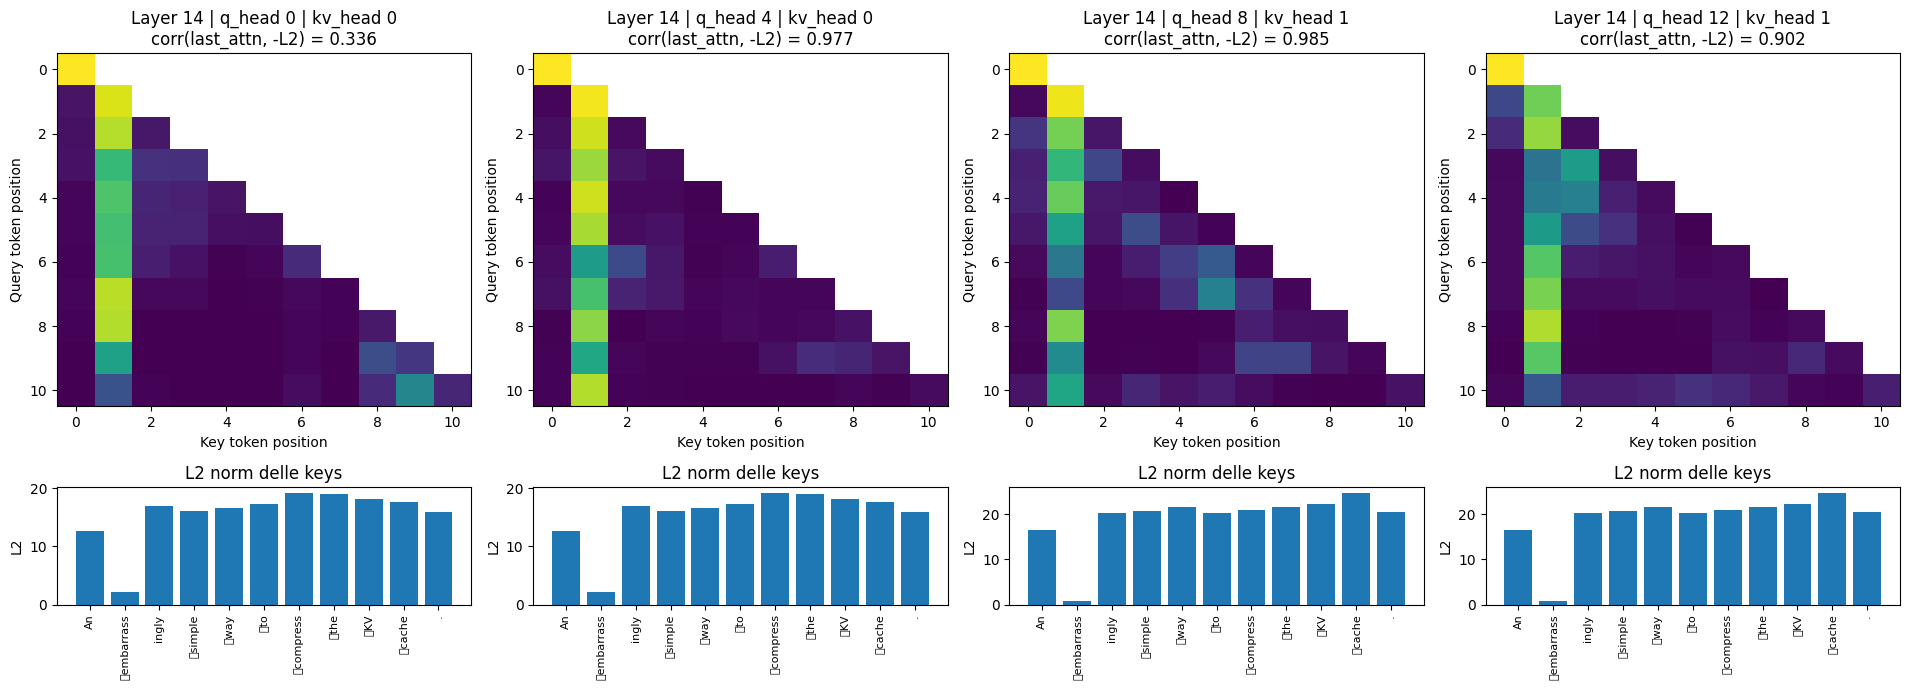

In [9]:
text = "An embarrassingly simple way to compress the KV cache."

plot_attention_l2_heatmap(
    model,
    tokenizer,
    text,
    layer_idx=14,
    q_heads=(0, 4, 8, 12),
    max_tokens=64,
    clean_tokens=True,
    exclude_first_for_corr=True,
)

# ALR

In [15]:
def debug_attention_l2_shapes(attn_full, l2, cache_len, layer_idx, q_head, kv_head):
    print(
        f"layer={layer_idx} | q_head={q_head} | kv_head={kv_head} | "
        f"attn_full.shape={tuple(attn_full.shape)} | "
        f"l2.shape={tuple(l2.shape)} | "
        f"cache_len={cache_len}"
    )

In [16]:
def extract_attention_over_cache(attn_full, cache_len):
    """
    attn_full: attention del decode step.
      shape attesa: [key_len]

    cache_len:
      numero reale di token nella KV cache.

    Ritorna:
      attention solo sui token cached, shape [cache_len]
    """

    attn_full = attn_full.detach().float().cpu().flatten()
    key_len = attn_full.shape[0]

    # Caso tipico: attention su cache + token corrente
    if key_len == cache_len + 1:
        return attn_full[:cache_len]

    # Caso: attention solo sulla cache
    if key_len == cache_len:
        return attn_full

    # Caso più lungo del previsto: di solito le prime cache_len posizioni
    # corrispondono ai token cached.
    if key_len > cache_len + 1:
        print(
            f"Warning: key_len={key_len}, cache_len={cache_len}. "
            f"Uso le prime cache_len posizioni."
        )
        return attn_full[:cache_len]

    # Caso problematico: l'attention non contiene abbastanza posizioni
    raise ValueError(
        f"Attention troppo corta: key_len={key_len}, cache_len={cache_len}. "
        "Probabilmente output_attentions con cache non sta restituendo "
        "l'attention completa. Prova a ricaricare il modello con "
        "attn_implementation='eager'."
    )

In [17]:
def compute_alr_from_attention_and_l2(
    attn_scores,
    l2_scores,
    normalize_attention=True,
):
    """
    attn_scores: [T]
    l2_scores:   [T]
    """

    attn = attn_scores.detach().float().cpu().flatten()
    l2 = l2_scores.detach().float().cpu().flatten()

    if attn.shape[0] != l2.shape[0]:
        raise ValueError(
            f"Mismatch ALR: attn length={attn.shape[0]}, "
            f"l2 length={l2.shape[0]}"
        )

    T = attn.shape[0]

    if normalize_attention:
        attn = attn / (attn.sum() + 1e-8)

    # L2 compression: elimina prima i token con L2 più alta
    l2_drop_order = torch.argsort(l2, descending=True)

    # Compressione ideale: elimina prima i token con attention più bassa
    ideal_drop_order = torch.argsort(attn, descending=False)

    l2_cumulative_loss = torch.cumsum(attn[l2_drop_order], dim=0)
    ideal_cumulative_loss = torch.cumsum(attn[ideal_drop_order], dim=0)

    y = l2_cumulative_loss - ideal_cumulative_loss
    y = torch.clamp(y, min=0.0)

    return {
        "alr_sum": y.sum().item(),
        "alr_mean": y.mean().item(),
    }

In [18]:
@torch.no_grad()
def scan_alr_qwen_decode_step(
    model,
    tokenizer,
    texts,
    max_tokens=512,
    normalize_attention=True,
    debug_shapes=False,
):
    """
    Calcola ALR per ogni:
      - prompt
      - layer
      - query head

    Usa la lunghezza reale della KV cache, non solo input_ids.shape[1].
    """

    device = next(model.parameters()).device
    cfg = get_model_cfg(model)

    num_layers = cfg.num_hidden_layers
    num_q_heads = cfg.num_attention_heads
    num_kv_heads = getattr(cfg, "num_key_value_heads", num_q_heads)
    group_size = num_q_heads // num_kv_heads

    rows = []

    for text_id, text in enumerate(texts):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=max_tokens,
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        batch_size = inputs["input_ids"].shape[0]

        # =====================
        # PREFILL
        # =====================
        prefill_out = model(
            **inputs,
            use_cache=True,
            return_dict=True,
        )

        cache = prefill_out.past_key_values

        # Lunghezza reale cache da layer 0
        K0, _ = get_cache_layer(cache, 0)
        cache_len = K0.shape[2]

        # Token successivo greedy, usato solo come query diagnostica
        next_token = prefill_out.logits[:, -1, :].argmax(dim=-1, keepdim=True)

        # =====================
        # DECODE STEP CON ATTENTION
        # =====================
        attention_mask_step = torch.ones(
            (batch_size, cache_len + 1),
            device=device,
            dtype=torch.long,
        )

        cache_position = torch.tensor(
            [cache_len],
            device=device,
            dtype=torch.long,
        )

        decode_out = model(
            input_ids=next_token,
            attention_mask=attention_mask_step,
            past_key_values=cache,
            cache_position=cache_position,
            use_cache=True,
            output_attentions=True,
            return_dict=True,
        )

        if decode_out.attentions is None or decode_out.attentions[0] is None:
            raise RuntimeError(
                "Le attention non sono disponibili. "
                "Ricarica il modello con attn_implementation='eager'."
            )

        # =====================
        # ALR PER LAYER/HEAD
        # =====================
        for layer_idx in range(num_layers):
            K, V = get_cache_layer(cache, layer_idx)

            # Lunghezza reale per questo layer
            layer_cache_len = K.shape[2]

            for q_head in range(num_q_heads):
                kv_head = q_head // group_size

                # shape tipica:
                # [B, H_q, query_len=1, key_len]
                attn_full = (
                    decode_out.attentions[layer_idx][0, q_head, 0]
                    .detach()
                    .float()
                    .cpu()
                )

                keys = K[0, kv_head].detach().float().cpu()
                l2 = keys.pow(2).sum(dim=-1).sqrt()

                if debug_shapes:
                    debug_attention_l2_shapes(
                        attn_full=attn_full,
                        l2=l2,
                        cache_len=layer_cache_len,
                        layer_idx=layer_idx,
                        q_head=q_head,
                        kv_head=kv_head,
                    )

                attn_cache = extract_attention_over_cache(
                    attn_full=attn_full,
                    cache_len=layer_cache_len,
                )

                alr = compute_alr_from_attention_and_l2(
                    attn_scores=attn_cache,
                    l2_scores=l2,
                    normalize_attention=normalize_attention,
                )

                rows.append({
                    "text_id": text_id,
                    "layer": layer_idx,
                    "q_head": q_head,
                    "kv_head": kv_head,
                    "seq_len": layer_cache_len,
                    "alr_sum": alr["alr_sum"],
                    "alr_mean": alr["alr_mean"],
                })

    return pd.DataFrame(rows)

In [19]:
def summarize_alr_by_layer_v2(alr_df):
    """
    Riassume ALR per layer.

    Usa anche una soglia relativa:
      high_alr_threshold = 75-esimo percentile globale
    così non scegliamo una soglia arbitraria.
    """

    high_alr_threshold = alr_df["alr_mean"].quantile(0.75)

    summary = (
        alr_df
        .groupby("layer")
        .agg(
            mean_alr=("alr_mean", "mean"),
            median_alr=("alr_mean", "median"),
            max_alr=("alr_mean", "max"),
            min_alr=("alr_mean", "min"),
            std_alr=("alr_mean", "std"),
            high_alr_fraction=(
                "alr_mean",
                lambda x: (x > high_alr_threshold).mean()
            ),
        )
        .reset_index()
        .sort_values("median_alr", ascending=False)
    )

    return summary, high_alr_threshold

In [20]:
def suggest_skip_layers_from_alr_v2(
    layer_summary,
    top_k=2,
    always_include_first_two=True,
):
    """
    Suggerisce i layer da NON comprimere.
    Prende i top_k layer con median_alr più alta.
    """

    skip_layers = (
        layer_summary
        .sort_values("median_alr", ascending=False)
        .head(top_k)["layer"]
        .tolist()
    )

    if always_include_first_two:
        skip_layers = sorted(set(skip_layers + [0, 1]))

    return tuple(skip_layers)

In [21]:
texts = [
    "An embarrassingly simple way to compress the KV cache. "
    "The model stores key and value tensors for each previous token during autoregressive decoding.",

    "The capital of France is Paris. The capital of Italy is Rome. "
    "The capital of Germany is Berlin. These facts are useful for retrieval tasks.",

    "Needle in a haystack evaluations test whether a language model can retrieve important information "
    "from a long context full of irrelevant tokens.",

    "Large language models based on decoder-only Transformers use self-attention layers, feed-forward networks, "
    "rotary positional embeddings, and key-value caches to speed up generation.",

    "In a passkey retrieval task, a secret number is inserted inside a long document, and the model must remember "
    "the number and output it correctly at the end.",
]

In [22]:
alr_df = scan_alr_qwen_decode_step(
    model,
    tokenizer,
    texts,
    max_tokens=128,
    normalize_attention=True,
    debug_shapes=False,
)

layer_summary, high_alr_threshold = summarize_alr_by_layer_v2(alr_df)
layer_summary.head(20)

,layer,mean_alr,median_alr,max_alr,min_alr,std_alr,high_alr_fraction
29,29,0.471060,0.493788,0.944527,0.000935,0.334784,0.6375
0,0,0.467983,0.447015,0.908190,0.002190,0.234952,0.8625
21,21,0.423778,0.412545,0.771257,0.190682,0.110412,0.9625
2,2,0.379818,0.357982,0.787940,0.090438,0.166701,0.7625
19,19,0.363734,0.336056,0.894949,0.000539,0.278606,0.5875
18,18,0.282507,0.258434,0.845065,0.012012,0.175271,0.5500
20,20,0.314266,0.253365,0.850124,0.000001,0.306057,0.5125
27,27,0.288747,0.234127,0.928466,0.008353,0.235055,0.5125
1,1,0.274124,0.218675,0.871560,0.064079,0.186665,0.4750
32,32,0.184184,0.165834,0.512159,0.034893,0.099688,0.2375


In [23]:
suggested_skip_layers = suggest_skip_layers_from_alr_v2(
    layer_summary,
    top_k=2,
    always_include_first_two=True,
)

suggested_skip_layers

(0, 1, 29)

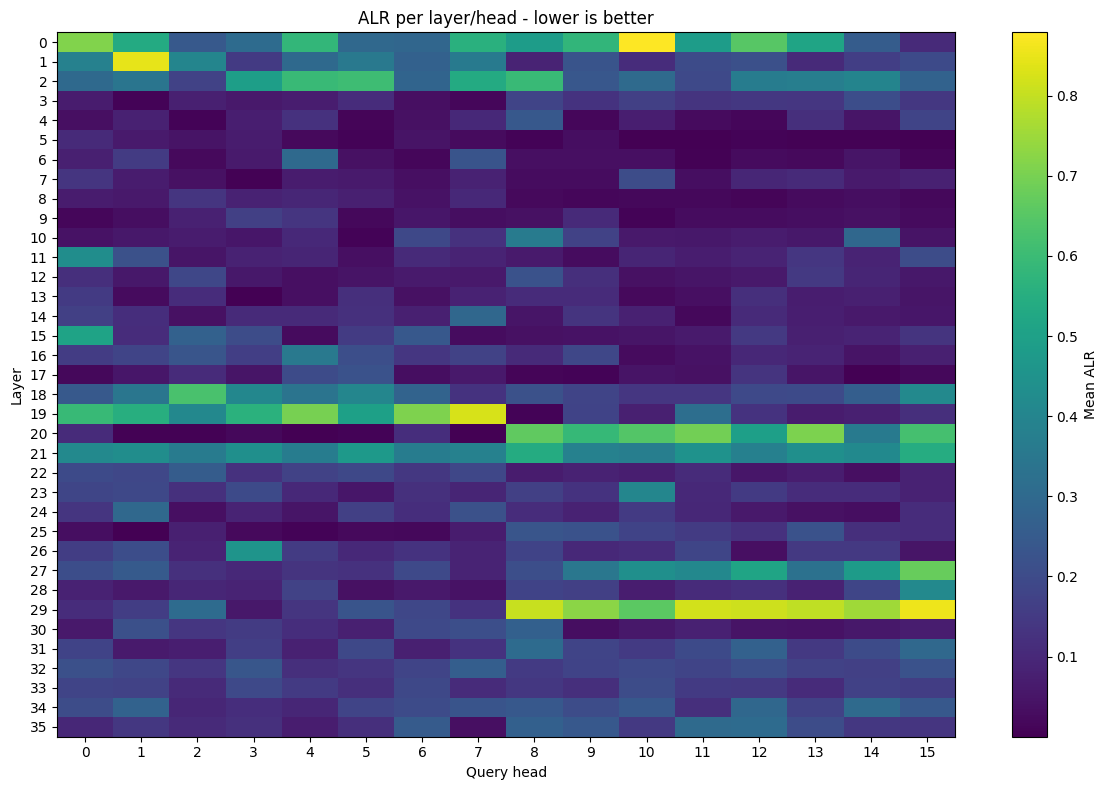

In [24]:
def plot_alr_heatmap(alr_df):
    pivot = (
        alr_df
        .groupby(["layer", "q_head"])["alr_mean"]
        .mean()
        .unstack()
    )

    plt.figure(figsize=(12, 8))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="Mean ALR")
    plt.xlabel("Query head")
    plt.ylabel("Layer")
    plt.title("ALR per layer/head - lower is better")
    plt.xticks(range(pivot.shape[1]), pivot.columns)
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.tight_layout()
    plt.show()


plot_alr_heatmap(alr_df)

# PASSKEY

In [45]:
@torch.no_grad()
def compress_cache(
    cache,
    keep_ratio=0.5,
    prune_after=1024,
    strategy="low_l2",
    skip_layers=(),
):
    for layer_idx, layer in enumerate(cache.layers):

        if layer_idx in skip_layers:
            continue

        K = layer.keys
        V = layer.values

        B, H_kv, T, D = K.shape

        if T < prune_after or keep_ratio >= 1.0:
            continue

        tokens_to_keep = max(1, min(math.ceil(keep_ratio * T), T))

        if strategy == "low_l2":
            scores = K.float().square().sum(dim=-1)
            largest = False

        elif strategy == "high_l2":
            scores = K.float().square().sum(dim=-1)
            largest = True

        elif strategy == "random":
            scores = torch.rand(B, H_kv, T, device=K.device)
            largest = False

        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        keep_idx = torch.topk(
            scores,
            k=tokens_to_keep,
            dim=-1,
            largest=largest,
            sorted=False,
        ).indices

        keep_idx = keep_idx.sort(dim=-1).values
        gather_idx = keep_idx.unsqueeze(-1).expand(-1, -1, -1, D)

        layer.keys = torch.gather(K, dim=2, index=gather_idx).contiguous()
        layer.values = torch.gather(V, dim=2, index=gather_idx).contiguous()

    return cache

In [27]:
def kv_cache_size_mb(cache):
    total_bytes = 0

    for layer in cache.layers:
        total_bytes += layer.keys.numel() * layer.keys.element_size()
        total_bytes += layer.values.numel() * layer.values.element_size()

    return total_bytes / 1024**2


def theoretical_kv_cache_size_mb(model, seq_len, batch_size=1):
    cfg = model.config

    L = cfg.num_hidden_layers
    H_q = cfg.num_attention_heads
    H_kv = cfg.num_key_value_heads

    head_dim = getattr(cfg, "head_dim", None)
    if head_dim is None:
        head_dim = cfg.hidden_size // H_q

    bytes_per_value = next(model.parameters()).element_size()

    total_bytes = (
        batch_size
        * L
        * 2
        * H_kv
        * seq_len
        * head_dim
        * bytes_per_value
    )

    return total_bytes / 1024**2

In [30]:
def make_passkey_prompt(tokenizer, target_tokens=2048, seed=0, depth=0.5):
    random.seed(seed)

    pass_key = str(random.randint(10000, 99999))

    intro = (
        "There is an important information hidden inside a lot of irrelevant text. "
        "Find it and remember it. I will ask you about it at the end.\n\n"
    )

    needle = f"The pass key is {pass_key}. Remember it. {pass_key} is the pass key.\n\n"

    question = "What is the pass key? The pass key is"

    garbage_sentence = (
        "The grass is green. The sky is blue. The sun is yellow. "
        "Here we go. There and back again. "
    )

    fixed_text = intro + needle + question
    fixed_tokens = len(tokenizer(fixed_text, add_special_tokens=False).input_ids)

    garbage_budget = max(0, target_tokens - fixed_tokens)

    garbage_text = garbage_sentence * ((garbage_budget // 20) + 100)
    garbage_ids = tokenizer(garbage_text, add_special_tokens=False).input_ids[:garbage_budget]

    split = int(len(garbage_ids) * depth)

    prefix = tokenizer.decode(garbage_ids[:split], skip_special_tokens=True)
    suffix = tokenizer.decode(garbage_ids[split:], skip_special_tokens=True)

    context = intro + prefix + "\n\n" + needle + suffix + "\n\n"

    return context, question, pass_key

In [53]:
@torch.no_grad()
def generate_passkey_answer(
    model,
    tokenizer,
    context,
    question,
    max_new_tokens=8,
    use_compression=False,
    keep_ratio=0.6,
    prune_after=1024,
    chunk_size=512,
    strategy="low_l2",
    skip_layers=(),
):
    device = next(model.parameters()).device

    context_inputs = tokenizer(context, return_tensors="pt").to(device)
    question_inputs = tokenizer(
        question,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(device)

    context_ids = context_inputs["input_ids"]
    question_ids = question_inputs["input_ids"]

    batch_size = context_ids.shape[0]

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    # =====================
    # PREFILL CONTEXT ONLY
    # =====================
    t0 = time.perf_counter()

    cache = None
    logical_pos = 0
    out = None

    for start in range(0, context_ids.shape[1], chunk_size):
        chunk = context_ids[:, start:start + chunk_size]
        chunk_len = chunk.shape[1]

        if cache is None:
            attention_mask = torch.ones(
                (batch_size, chunk_len),
                device=device,
                dtype=torch.long,
            )

            out = model(
                input_ids=chunk,
                attention_mask=attention_mask,
                use_cache=True,
                return_dict=True,
            )

        else:
            past_len = cache.layers[0].keys.shape[2]

            attention_mask = torch.ones(
                (batch_size, past_len + chunk_len),
                device=device,
                dtype=torch.long,
            )

            cache_position = torch.arange(
                logical_pos,
                logical_pos + chunk_len,
                device=device,
                dtype=torch.long,
            )

            out = model(
                input_ids=chunk,
                attention_mask=attention_mask,
                past_key_values=cache,
                cache_position=cache_position,
                use_cache=True,
                return_dict=True,
            )

        cache = out.past_key_values
        logical_pos += chunk_len

    # =====================
    # COMPRESS CONTEXT CACHE ONCE
    # =====================
    if use_compression:
        cache = compress_cache(
            cache,
            keep_ratio=keep_ratio,
            prune_after=prune_after,
            strategy=strategy,
            skip_layers=skip_layers,
        )

    # =====================
    # PROCESS QUESTION USING COMPRESSED CACHE
    # =====================
    q_len = question_ids.shape[1]
    past_len = cache.layers[0].keys.shape[2]

    attention_mask = torch.ones(
        (batch_size, past_len + q_len),
        device=device,
        dtype=torch.long,
    )

    cache_position = torch.arange(
        logical_pos,
        logical_pos + q_len,
        device=device,
        dtype=torch.long,
    )

    out = model(
        input_ids=question_ids,
        attention_mask=attention_mask,
        past_key_values=cache,
        cache_position=cache_position,
        use_cache=True,
        return_dict=True,
    )

    cache = out.past_key_values
    logical_pos += q_len

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    prefill_time = time.perf_counter() - t0

    # Ora il primo token della risposta dipende dalla cache compressa
    next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)

    generated = []

    # =====================
    # DECODE ANSWER
    # =====================
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t0 = time.perf_counter()

    for step in range(max_new_tokens):
        generated.append(next_token)

        if step == max_new_tokens - 1:
            break

        past_len = cache.layers[0].keys.shape[2]

        attention_mask_step = torch.ones(
            (batch_size, past_len + 1),
            device=device,
            dtype=torch.long,
        )

        cache_position = torch.tensor(
            [logical_pos],
            device=device,
            dtype=torch.long,
        )

        out = model(
            input_ids=next_token,
            attention_mask=attention_mask_step,
            past_key_values=cache,
            cache_position=cache_position,
            use_cache=True,
            return_dict=True,
        )

        cache = out.past_key_values
        logical_pos += 1

        next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    decode_time = time.perf_counter() - t0

    generated_ids = torch.cat(generated, dim=-1)
    generated_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True,
    )

    final_cache_mb = kv_cache_size_mb(cache)

    uncompressed_cache_mb = theoretical_kv_cache_size_mb(
        model=model,
        seq_len=logical_pos,
        batch_size=batch_size,
    )

    memory_saved_percent = 100 * (
        1 - final_cache_mb / (uncompressed_cache_mb + 1e-8)
    )

    result = {
        "generated_text": generated_text,
        "context_tokens": context_ids.shape[1],
        "question_tokens": question_ids.shape[1],
        "total_prompt_tokens": context_ids.shape[1] + question_ids.shape[1],
        "prefill_time": prefill_time,
        "decode_time": decode_time,
        "decode_tok_s": max_new_tokens / max(decode_time, 1e-8),
        "final_cache_len": cache.layers[0].keys.shape[2],
        "final_cache_mb": final_cache_mb,
        "uncompressed_cache_mb": uncompressed_cache_mb,
        "memory_saved_percent": memory_saved_percent,
    }

    return result

In [15]:
def kv_cache_size_mb(cache):
    total_bytes = 0

    for layer in cache.layers:
        K = layer.keys
        V = layer.values

        total_bytes += K.numel() * K.element_size()
        total_bytes += V.numel() * V.element_size()

    return total_bytes / 1024**2

In [47]:
skip_layers = (0, 1, 29)

eval_configs = [
    {
        "config": "no_compression",
        "use_compression": False,
        "keep_ratio": 1.0,
        "skip_layers": (),
    },
    {
        "config": "low_l2_no_skip_keep50",
        "use_compression": True,
        "keep_ratio": 0.5,
        "skip_layers": (),
    },
    {
        "config": "low_l2_skip01_keep50",
        "use_compression": True,
        "keep_ratio": 0.5,
        "skip_layers": skip_layers,
    },
    {
        "config": "low_l2_no_skip_keep10",
        "use_compression": True,
        "keep_ratio": 0.1,
        "skip_layers": (),
    },
    {
        "config": "low_l2_skip01_keep10",
        "use_compression": True,
        "keep_ratio": 0.1,
        "skip_layers": skip_layers,
    },
]

In [59]:
context_lengths = [32768]
depths = [0.1, 0.5, 0.9]
seeds = [0]
rows = []

for context_len in context_lengths:
    for depth in depths:
        for seed in seeds:

            context, question, answer = make_passkey_prompt(
                tokenizer,
                target_tokens=context_len,
                seed=seed,
                depth=depth,
            )

            for cfg in eval_configs:

                print(
                    f"{cfg['config']} | "
                    f"context={context_len} | depth={depth} | seed={seed}"
                )

                res = generate_passkey_answer(
                    model,
                    tokenizer,
                    context,
                    question,
                    max_new_tokens=8,
                    use_compression=cfg["use_compression"],
                    keep_ratio=cfg["keep_ratio"],
                    prune_after=1024,
                    chunk_size=512,
                    strategy="low_l2",
                    skip_layers=cfg["skip_layers"],
                )

                generated = res["generated_text"].strip()
                correct = generated.startswith(answer)

                rows.append({
                "config": cfg["config"],
                "context_len": context_len,
                "depth": depth,
                "answer": answer,
                "generated": generated,
                "correct": correct,
                "keep_ratio": cfg["keep_ratio"],
                "compression_ratio": 1 - cfg["keep_ratio"],
                "final_cache_mb": res["final_cache_mb"],
                "uncompressed_cache_mb": res["uncompressed_cache_mb"],
                "memory_saved_percent": res["memory_saved_percent"],
            })

df = pd.DataFrame(rows)
df

no_compression | context=32768 | depth=0.1 | seed=0
low_l2_no_skip_keep50 | context=32768 | depth=0.1 | seed=0
low_l2_skip01_keep50 | context=32768 | depth=0.1 | seed=0
low_l2_no_skip_keep10 | context=32768 | depth=0.1 | seed=0
low_l2_skip01_keep10 | context=32768 | depth=0.1 | seed=0
no_compression | context=32768 | depth=0.5 | seed=0
low_l2_no_skip_keep50 | context=32768 | depth=0.5 | seed=0
low_l2_skip01_keep50 | context=32768 | depth=0.5 | seed=0
low_l2_no_skip_keep10 | context=32768 | depth=0.5 | seed=0
low_l2_skip01_keep10 | context=32768 | depth=0.5 | seed=0
no_compression | context=32768 | depth=0.9 | seed=0
low_l2_no_skip_keep50 | context=32768 | depth=0.9 | seed=0
low_l2_skip01_keep50 | context=32768 | depth=0.9 | seed=0
low_l2_no_skip_keep10 | context=32768 | depth=0.9 | seed=0
low_l2_skip01_keep10 | context=32768 | depth=0.9 | seed=0


,config,context_len,depth,answer,generated,correct,keep_ratio,compression_ratio,final_cache_mb,uncompressed_cache_mb,memory_saved_percent
0,no_compression,32768,0.1,60494,60494. Remember,True,1.0,0.0,1152.316406,1152.316406,8.678058e-10
1,low_l2_no_skip_keep50,32768,0.1,60494,60494. Remember,True,0.5,0.5,576.457031,1152.316406,4.997407e+01
2,low_l2_skip01_keep50,32768,0.1,60494,60494.,True,0.5,0.5,624.445312,1152.316406,4.580956e+01
3,low_l2_no_skip_keep10,32768,0.1,60494,60494. It,True,0.1,0.9,115.769531,1152.316406,8.995332e+01
4,low_l2_skip01_keep10,32768,0.1,60494,60494. It,True,0.1,0.9,202.148438,1152.316406,8.245721e+01
5,no_compression,32768,0.5,60494,60494. Remember,True,1.0,0.0,1152.316406,1152.316406,8.678058e-10
6,low_l2_no_skip_keep50,32768,0.5,60494,60494. Remember,True,0.5,0.5,576.457031,1152.316406,4.997407e+01
7,low_l2_skip01_keep50,32768,0.5,60494,60494. Remember,True,0.5,0.5,624.445312,1152.316406,4.580956e+01
8,low_l2_no_skip_keep10,32768,0.5,60494,60494.,True,0.1,0.9,115.769531,1152.316406,8.995332e+01
9,low_l2_skip01_keep10,32768,0.5,60494,60494. Remember,True,0.1,0.9,202.148438,1152.316406,8.245721e+01


In [60]:
summary = (
    df
    .groupby(["config", "context_len", "keep_ratio", "compression_ratio"])
    .agg(
        accuracy=("correct", "mean"),
        final_cache_mb=("final_cache_mb", "mean"),
        uncompressed_cache_mb=("uncompressed_cache_mb", "mean"),
        memory_saved_percent=("memory_saved_percent", "mean"),
    )
    .reset_index()
)

summary["accuracy"] = (summary["accuracy"] * 100).round(2)
summary["final_cache_mb"] = summary["final_cache_mb"].round(2)
summary["uncompressed_cache_mb"] = summary["uncompressed_cache_mb"].round(2)
summary["memory_saved_percent"] = summary["memory_saved_percent"].round(2)

summary

,config,context_len,keep_ratio,compression_ratio,accuracy,final_cache_mb,uncompressed_cache_mb,memory_saved_percent
0,low_l2_no_skip_keep10,32768,0.1,0.9,100.0,115.77,1152.32,89.95
1,low_l2_no_skip_keep50,32768,0.5,0.5,100.0,576.46,1152.32,49.97
2,low_l2_skip01_keep10,32768,0.1,0.9,100.0,202.15,1152.32,82.46
3,low_l2_skip01_keep50,32768,0.5,0.5,100.0,624.45,1152.32,45.81
4,no_compression,32768,1.0,0.0,100.0,1152.32,1152.32,0.00


In [70]:
def make_distractor_passkey_prompt(
    tokenizer,
    target_tokens=8192,
    seed=0,
    depth=0.5,
    passkey_digits=5,
):
    random.seed(seed)

    pass_key = "".join(str(random.randint(0, 9)) for _ in range(passkey_digits))

    intro = (
        "There is one important pass key hidden inside a long document. "
        "Many other numbers are irrelevant distractors. "
        "Find the true pass key and remember it.\n\n"
    )

    needle = (
        f"IMPORTANT INFORMATION: the true pass key is {pass_key}. "
        f"Only {pass_key} is the pass key.\n\n"
    )

    question = "What is the true pass key? Answer only the pass key:"

    distractor_templates = [
        "The ticket number is {num}. ",
        "The reference code is {num}. ",
        "The room number is {num}. ",
        "The invoice ID is {num}. ",
        "The archive label is {num}. ",
        "The temporary access code is {num}. ",
        "The user identifier is {num}. ",
        "The checkpoint number is {num}. ",
    ]

    def random_number():
        while True:
            num = "".join(str(random.randint(0, 9)) for _ in range(passkey_digits))
            if num != pass_key:
                return num

    garbage_parts = []

    while True:
        template = random.choice(distractor_templates)
        num = random_number()
        garbage_parts.append(template.format(num=num))

        garbage_text = "".join(garbage_parts)
        fixed_text = intro + needle + question

        total_tokens = len(
            tokenizer(
                fixed_text + garbage_text,
                add_special_tokens=False,
            ).input_ids
        )

        if total_tokens >= target_tokens:
            break

    fixed_text = intro + needle + question
    fixed_tokens = len(tokenizer(fixed_text, add_special_tokens=False).input_ids)

    garbage_budget = max(0, target_tokens - fixed_tokens)

    garbage_ids = tokenizer(
        "".join(garbage_parts),
        add_special_tokens=False,
    ).input_ids[:garbage_budget]

    split = int(len(garbage_ids) * depth)

    prefix = tokenizer.decode(garbage_ids[:split], skip_special_tokens=True)
    suffix = tokenizer.decode(garbage_ids[split:], skip_special_tokens=True)

    context = intro + prefix + "\n\n" + needle + suffix + "\n\n"

    return context, question, pass_key

In [71]:
skip_layers = (0, 1, 29)

configs = [
    {
        "config": "no_compression",
        "use_compression": False,
        "keep_ratio": 1.0,
        "skip_layers": (),
    },
    {
        "config": "low_l2_skip01_keep50",
        "use_compression": True,
        "keep_ratio": 0.5,
        "skip_layers": skip_layers,
    },
    {
        "config": "low_l2_skip01_keep10",
        "use_compression": True,
        "keep_ratio": 0.1,
        "skip_layers": skip_layers,
    },
]

In [65]:
import re

def extract_first_number(text):
    match = re.search(r"\d+", text)
    if match is None:
        return ""
    return match.group(0)

prediction = extract_first_number(generated)
correct = prediction == answer

In [72]:
context_lengths = [8192]
depths = [0.1, 0.5, 0.9]
seeds = [0]
rows = []

for context_len in context_lengths:
    for depth in depths:
        for seed in seeds:

            context, question, answer = make_distractor_passkey_prompt(
                tokenizer,
                target_tokens=context_len,
                seed=seed,
                depth=depth,
                passkey_digits=8,
            )
            for cfg in eval_configs:

                print(
                    f"{cfg['config']} | "
                    f"context={context_len} | depth={depth} | seed={seed}"
                )

                res = generate_passkey_answer(
                    model,
                    tokenizer,
                    context,
                    question,
                    max_new_tokens=8,
                    use_compression=cfg["use_compression"],
                    keep_ratio=cfg["keep_ratio"],
                    prune_after=1024,
                    chunk_size=512,
                    strategy="low_l2",
                    skip_layers=cfg["skip_layers"],
                )

                generated = res["generated_text"].strip()
                prediction = extract_first_number(generated)
                correct = prediction == answer

                rows.append({
                "config": cfg["config"],
                "context_len": context_len,
                "depth": depth,
                "answer": answer,
                "generated": generated,
                "correct": correct,
                "keep_ratio": cfg["keep_ratio"],
                "compression_ratio": 1 - cfg["keep_ratio"],
                "final_cache_mb": res["final_cache_mb"],
                "uncompressed_cache_mb": res["uncompressed_cache_mb"],
                "memory_saved_percent": res["memory_saved_percent"],
                "prediction": prediction,
            })

df = pd.DataFrame(rows)
df

no_compression | context=8192 | depth=0.1 | seed=0
low_l2_no_skip_keep50 | context=8192 | depth=0.1 | seed=0
low_l2_skip01_keep50 | context=8192 | depth=0.1 | seed=0
low_l2_no_skip_keep10 | context=8192 | depth=0.1 | seed=0
low_l2_skip01_keep10 | context=8192 | depth=0.1 | seed=0
no_compression | context=8192 | depth=0.5 | seed=0
low_l2_no_skip_keep50 | context=8192 | depth=0.5 | seed=0
low_l2_skip01_keep50 | context=8192 | depth=0.5 | seed=0
low_l2_no_skip_keep10 | context=8192 | depth=0.5 | seed=0
low_l2_skip01_keep10 | context=8192 | depth=0.5 | seed=0
no_compression | context=8192 | depth=0.9 | seed=0
low_l2_no_skip_keep50 | context=8192 | depth=0.9 | seed=0
low_l2_skip01_keep50 | context=8192 | depth=0.9 | seed=0
low_l2_no_skip_keep10 | context=8192 | depth=0.9 | seed=0
low_l2_skip01_keep10 | context=8192 | depth=0.9 | seed=0


,config,context_len,depth,answer,generated,correct,keep_ratio,compression_ratio,final_cache_mb,uncompressed_cache_mb,memory_saved_percent,prediction
0,no_compression,8192,0.1,66048764,6604876,False,1.0,0.0,288.316406,288.316406,3.468414e-09,6604876
1,low_l2_no_skip_keep50,8192,0.1,66048764,6604876,False,0.5,0.5,144.527344,288.316406,4.987197e+01,6604876
2,low_l2_skip01_keep50,8192,0.1,66048764,6604876,False,0.5,0.5,156.509766,288.316406,4.571597e+01,6604876
3,low_l2_no_skip_keep10,8192,0.1,66048764,6666666,False,0.1,0.9,29.496094,288.316406,8.976954e+01,6666666
4,low_l2_skip01_keep10,8192,0.1,66048764,666666,False,0.1,0.9,51.064453,288.316406,8.228875e+01,666666
5,no_compression,8192,0.5,66048764,6604876,False,1.0,0.0,288.316406,288.316406,3.468414e-09,6604876
6,low_l2_no_skip_keep50,8192,0.5,66048764,6604876,False,0.5,0.5,144.527344,288.316406,4.987197e+01,6604876
7,low_l2_skip01_keep50,8192,0.5,66048764,6604876,False,0.5,0.5,156.509766,288.316406,4.571597e+01,6604876
8,low_l2_no_skip_keep10,8192,0.5,66048764,6666666,False,0.1,0.9,29.496094,288.316406,8.976954e+01,6666666
9,low_l2_skip01_keep10,8192,0.5,66048764,666666,False,0.1,0.9,51.064453,288.316406,8.228875e+01,666666
